# GenericEDA

## Generic Motor Dataset Analysis

Welcome to **GenericEDA**, an interactive Exploratory Data Analysis (EDA) notebook designed for generic motor datasets.

### Supported File Formats
- Excel (.xlsx, .xls)
- CSV (.csv)
- TXT (.txt)

### Workflow

1. Upload Dataset
2. Dataset Summary
3. Data Quality Analysis
4. Missing Value Analysis
5. Outlier Analysis
6. Data Cleaning
7. Data Visualization
8. Export Cleaned Dataset

---

In [2]:
import os
import sys
project_path= os.getcwd()

if project_path not in sys.path:
    sys.path.append(project_path)

print("Current Directory:" , os.getcwd())
print(os.listdir("data"))

Current Directory: C:\Users\MONSTER\GENERİC_EDA
['.ipynb_checkpoints', 'campus_placement_data.csv', 'engine1_normalized.xlsx', 'generic_eda_test_100_columns.csv', 'iyor.csv', 'measures_v2.csv', 'train_FD001.txt']


In [3]:
print("Current Folder:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())
print("\nData Folder:")
print(os.listdir("data"))

Current Folder:
C:\Users\MONSTER\GENERİC_EDA

Files:
['.ipynb_checkpoints', 'data', 'figures', 'GenericEDA.ipynb', 'outputs', 'utils']

Data Folder:
['.ipynb_checkpoints', 'campus_placement_data.csv', 'engine1_normalized.xlsx', 'generic_eda_test_100_columns.csv', 'iyor.csv', 'measures_v2.csv', 'train_FD001.txt']


In [6]:
from IPython.display import display, Markdown
from utils.session import EDASession

import pandas as pd
import numpy as np

from pathlib import Path
import ipywidgets as widgets

pd.set_option("display.float_format", "{:.3f}".format)

from utils.loader import load_dataset
from utils.summary import generate_summary
from utils.quality import generate_quality_report

from utils.missing import (
    analyze_missing,
    plot_missing_bar,
    plot_missing_heatmap
)

from utils.outlier import detect_outliers

from utils.cleaning import *

from utils.visualization import *

from utils.export import export_dataset

## 📂 Upload Dataset

Upload a motor dataset to begin the analysis.

Supported formats:

- Excel (.xlsx, .xls)
- CSV (.csv)
- TXT (.txt)

In [9]:
#### display(Markdown("## 📂 Dataset Selection"))

DATA_DIR = Path("data")

SUPPORTED_EXTENSIONS = {
    ".csv",
    ".xlsx",
    ".xls",
    ".txt"
}

dataset_files = sorted(
    [
        file
        for file in DATA_DIR.iterdir()
        if file.is_file()
        and file.suffix.lower() in SUPPORTED_EXTENSIONS
    ],
    key=lambda x: x.name.lower()
)

if not dataset_files:
    raise FileNotFoundError(
        "No supported dataset files were found in the data folder."
    )

print("Available Datasets:\n")

for i, file in enumerate(dataset_files, start=1):
    print(f"{i}. {file.name}")

while True:

    try:
        selection = int(
            input("\nSelect dataset number: ")
        )

        if 1 <= selection <= len(dataset_files):
            break

        print("Invalid selection. Please choose a valid number.")

    except ValueError:
        print("Please enter a number.")


file_path = dataset_files[selection - 1]
file_name = file_path.name

df = load_dataset(file_path)
session = EDASession(df)

display(
    Markdown(
        "### ✅ Dataset Loaded Successfully"
    )
)

print(f"File Name : {file_name}")
print(f"Rows      : {df.shape[0]}")
print(f"Columns   : {df.shape[1]}")

if df.shape[1] >= 100:
    print(
        "ℹ️ Large dataset detected: "
        "100 or more columns are supported."
    )

Available Datasets:

1. campus_placement_data.csv
2. engine1_normalized.xlsx
3. generic_eda_test_100_columns.csv
4. iyor.csv
5. measures_v2.csv
6. train_FD001.txt



Select dataset number:  4


### ✅ Dataset Loaded Successfully

File Name : iyor.csv
Rows      : 5150
Columns   : 19


## 📊 Dataset Summary

This section provides a general overview of the uploaded dataset, including:

- Dataset dimensions
- Column information
- Descriptive statistics
- Memory usage

In [12]:
summary = generate_summary(df)

display(Markdown("### 📌 General Information"))

summary_info = pd.DataFrame({
    "Property": [
        "Rows",
        "Columns",
        "Memory Usage (MB)"
    ],
    "Value": [
        summary["shape"]["rows"],
        summary["shape"]["columns"],
        summary["memory_usage_mb"]
    ]
})

display(summary_info)

display(Markdown("### 📋 Column Information"))
display(summary["columns"])

display(Markdown("### 📈 Descriptive Statistics"))
display(summary["statistics"])

C:\Users\MONSTER\anaconda3\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\MONSTER\anaconda3\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\MONSTER\anaconda3\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\MONSTER\anaconda3\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


### 📌 General Information

,Property,Value
0,Rows,5150.000
1,Columns,19.000
2,Memory Usage (MB),3.840


### 📋 Column Information

,Column,Data Type,Non-Null Count,Null Count
record_id,record_id,int64,5150,0
motor_id,motor_id,object,5150,0
timestamp,timestamp,object,5133,17
motor_status,motor_status,object,5129,21
temperature_c,temperature_c,object,4741,409
rpm,rpm,object,5147,3
vibration_mm_s,vibration_mm_s,float64,4225,925
pressure_bar,pressure_bar,object,4541,609
oil_level_pct,oil_level_pct,object,3874,1276
humidity_pct,humidity_pct,float64,5150,0


### 📈 Descriptive Statistics

,record_id,vibration_mm_s,humidity_pct,current_a,power_kw,completely_empty
count,5150.000,4225.000,5150.000,5150.000,5150.000,0.000
mean,102505.296,NaN,NaN,NaN,NaN,NaN
std,1446.032,NaN,NaN,NaN,NaN,NaN
min,100001.000,-inf,-inf,-inf,-inf,NaN
25%,101254.250,2.490,36.770,14.620,3.274,NaN
50%,102508.500,3.249,55.290,17.910,4.075,NaN
75%,103756.750,3.987,72.490,21.367,4.865,NaN
max,105000.000,inf,inf,inf,inf,NaN


## 🔍 Data Quality Analysis

This section evaluates the overall quality of the dataset by identifying common data quality issues.

The following checks are performed:

- Missing values
- Duplicate rows
- Infinite values
- Constant columns
- Empty columns

In [15]:
quality_report = generate_quality_report(df)

display(Markdown("### 📊 Data Quality Report"))

# General Quality Summary
quality_summary = pd.DataFrame({
    "Metric": [
        "Duplicate Count",
        "Duplicate Percentage (%)",
        "Numeric Columns",
        "Categorical Columns",
        "Constant Columns",
        "Empty Columns"
    ],
    "Value": [
        quality_report["duplicate_rows"]["Duplicate Count"],
        quality_report["duplicate_rows"]["Duplicate Percentage"],
        quality_report["column_types"]["Numeric Columns"],
        quality_report["column_types"]["Categorical Columns"],
        len(quality_report["constant_columns"]),
        len(quality_report["empty_columns"])
    ]
})

display(quality_summary)

display(Markdown("### ⚠️ Missing Values"))
display(quality_report["missing_values"])

display(Markdown("### ♾️ Infinite Values"))
display(quality_report["infinite_values"])

display(Markdown("### 📝 Data Types"))
display(quality_report["data_types"])

display(Markdown("### 📌 Constant Columns"))

if quality_report["constant_columns"]:
    display(
        pd.DataFrame({
            "Constant Columns": quality_report["constant_columns"]
        })
    )
else:
    print("No constant columns found.")

display(Markdown("### 📂 Empty Columns"))

if quality_report["empty_columns"]:
    display(
        pd.DataFrame({
            "Empty Columns": quality_report["empty_columns"]
        })
    )
else:
    print("No empty columns found.")

### 📊 Data Quality Report

,Metric,Value
0,Duplicate Count,150.000
1,Duplicate Percentage (%),2.910
2,Numeric Columns,6.000
3,Categorical Columns,13.000
4,Constant Columns,2.000
5,Empty Columns,1.000


### ⚠️ Missing Values

,Missing Count,Missing Percentage
record_id,0,0.000
motor_id,0,0.000
timestamp,17,0.330
motor_status,21,0.410
temperature_c,409,7.940
rpm,3,0.060
vibration_mm_s,925,17.960
pressure_bar,609,11.830
oil_level_pct,1276,24.780
humidity_pct,0,0.000


### ♾️ Infinite Values

...

,Column,Data Type
record_id,record_id,int64
motor_id,motor_id,object
timestamp,timestamp,object
motor_status,motor_status,object
temperature_c,temperature_c,object
rpm,rpm,object
vibration_mm_s,vibration_mm_s,float64
pressure_bar,pressure_bar,object
oil_level_pct,oil_level_pct,object
humidity_pct,humidity_pct,float64


### 📌 Constant Columns

,Constant Columns
0,constant_column
1,completely_empty


### 📂 Empty Columns

,Empty Columns
0,completely_empty


## ⚠️ Missing Value Analysis

This section analyzes missing values in the dataset.

The following analyses are performed:

- Missing value summary
- Missing value distribution (Bar Chart)
- Missing value heatmap

This step is intended only for analysis. No changes are applied to the dataset.

In [18]:
missing_summary = analyze_missing(df)

display(Markdown("### 📋 Missing Value Summary"))
display(missing_summary)


### 📋 Missing Value Summary

,Column,Missing Count,Missing %
0,completely_empty,5150,100.000
1,operator,1763,34.230
2,oil_level_pct,1276,24.780
3,vibration_mm_s,925,17.960
4,pressure_bar,609,11.830
5,temperature_c,409,7.940
6,error_code,312,6.060
7,motor_status,21,0.410
8,timestamp,17,0.330
9,voltage_v,11,0.210


## 📈 Outlier Analysis

This section identifies potential outliers in the dataset.

The analysis can be performed using one of the following methods:

- IQR (Interquartile Range)
- Z-Score

No changes are applied to the dataset during this step.

Choose an outlier detection method:

- **IQR:** Recommended for skewed distributions and robust against extreme values.
- **Z-Score:** Recommended for approximately normally distributed data.

In [21]:
display(Markdown("### 📈 Select Outlier Detection Method"))

print("1. IQR")
print("2. Z-Score")

while True:

    choice = input(
        "\nEnter your choice (1/2): "
    ).strip()

    # ======================================================
    # IQR
    # ======================================================

    if choice == "1":

        # --------------------------------------------------
        # Step 1: Initial analysis with standard IQR = 1.5
        # --------------------------------------------------

        initial_multiplier = 1.5

        initial_report = detect_outliers(
            df,
            method="iqr",
            iqr_multiplier=initial_multiplier
        )

        display(
            Markdown(
                "### 📊 Initial IQR Analysis"
            )
        )

        print(
            f"Initial IQR multiplier: "
            f"{initial_multiplier}"
        )

        # --------------------------------------------------
        # Show only the useful percentage information first
        # --------------------------------------------------

        if not initial_report.empty:

            percentage_report = initial_report[
                [
                    "Column",
                    "Outlier Count",
                    "Outlier %"
                ]
            ].copy()

            display(
                percentage_report
            )

        else:

            print(
                "No outliers were detected."
            )

        # --------------------------------------------------
        # Step 2: User sees the data and chooses multiplier
        # --------------------------------------------------

        print("\nIQR Multiplier Guide")
        print("1.5 → Standard / balanced")
        print("2.0 → More tolerant")
        print("2.5 → More tolerant")
        print("3.0 → Very tolerant")

        while True:

            try:

                iqr_multiplier = float(
                    input(
                        "\nEnter IQR multiplier "
                        "(default: 1.5): "
                    ).strip()
                    or 1.5
                )

                if iqr_multiplier <= 0:
                    raise ValueError

                break

            except ValueError:

                print(
                    "❌ Please enter a positive number."
                )

        # --------------------------------------------------
        # Step 3: Generate final report
        # --------------------------------------------------

        report = detect_outliers(
            df,
            method="iqr",
            iqr_multiplier=iqr_multiplier
        )

        display(
            Markdown(
                f"### 📋 Final IQR Report "
                f"(Multiplier: {iqr_multiplier})"
            )
        )

        display(report)

        break

    # ======================================================
    # Z-SCORE
    # ======================================================

    elif choice == "2":

        while True:

            try:

                z_threshold = float(
                    input(
                        "\nEnter Z-Score threshold "
                        "(recommended: 3): "
                    ).strip()
                )

                if z_threshold <= 0:
                    raise ValueError

                break

            except ValueError:

                print(
                    "❌ Please enter a positive number."
                )

        report = detect_outliers(
            df,
            method="zscore",
            threshold=z_threshold
        )

        break

    else:

        print(
            "❌ Invalid selection. Please try again."
        )


display(Markdown("### 📋 Outlier Report"))
display(report)

### 📈 Select Outlier Detection Method

1. IQR
2. Z-Score



Enter your choice (1/2):  1


### 📊 Initial IQR Analysis

Initial IQR multiplier: 1.5


...


Enter IQR multiplier (default: 1.5):  2


### 📋 Final IQR Report (Multiplier: 2.0)

,Column,Method,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,current_a,IQR,45,0.880,1.260,34.710
1,vibration_mm_s,IQR,37,0.880,-0.493,6.967
2,power_kw,IQR,6,0.120,0.108,8.032


### 📋 Outlier Report

,Column,Method,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,current_a,IQR,45,0.880,1.260,34.710
1,vibration_mm_s,IQR,37,0.880,-0.493,6.967
2,power_kw,IQR,6,0.120,0.108,8.032


# 🧹 Data Cleaning

This section allows you to clean the dataset based on the previous analysis.

The cleaning process is divided into two parts:

- Missing Value Handling
- Outlier Handling

## 📝 Missing Value Handling

Choose how missing values should be handled.

In [25]:
display(Markdown("### Select Missing Value Handling Method"))

print("1. Fill with Mean")
print("2. Fill with Median")
print("3. Fill with Mode")
print("4. Remove Missing Rows")
print("5. Skip")

while True:

    choice = input("\nEnter your choice (1-5): ").strip()

    if choice == "1":
        new_df = fill_missing_mean(df)
        session.apply(
            new_df,
            operation="Missing Value Cleaning",
            details="Missing values filled with mean."
        )

        df = session.current_df
        print("✅ Missing values filled using Mean.")
        break

    elif choice == "2":
        new_df = fill_missing_median(df)

        session.apply(
            new_df,
            operation="Missing Value Cleaning",
            details="Missing values filled with median."
        )
        
        df = session.current_df
        print("✅ Missing values filled using Median.")
        break

    elif choice == "3":
        new_df = fill_missing_mode(df)

        session.apply(
            new_df,
            operation="Missing Value Cleaning",
            details="Missing values filled with mode."
        )
        
        df = session.current_df
        print("✅ Missing values filled using Mode.")
        break

    elif choice == "4":
        new_df = remove_missing_rows(df)

        session.apply(
            new_df,
            operation="Missing Row Removal",
            details="Rows containing missing values removed."
        )
        
        df = session.current_df
        print("✅ Rows containing missing values removed.")
        break

    elif choice == "5":
        print("⏭️ Missing value handling skipped.")
        break

    else:
        print("❌ Invalid selection. Please try again.")

before_duplicates = len(df)

df = remove_duplicates(df)

removed_duplicates = before_duplicates - len(df)

print(
    f"🗑️ Duplicate rows removed: {removed_duplicates}"
)

### Select Missing Value Handling Method

1. Fill with Mean
2. Fill with Median
3. Fill with Mode
4. Remove Missing Rows
5. Skip



Enter your choice (1-5):  2



✅ Operation recorded: Missing Value Cleaning
✅ Missing values filled using Median.
🗑️ Duplicate rows removed: 150


In [27]:
display(Markdown("### 📊 Updated Dataset"))

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

### 📊 Updated Dataset

Rows    : 5000
Columns : 19


## 📌 Outlier Handling

Choose a method to handle detected outliers.

The selected method will be applied to all numeric columns.

In [30]:
display(Markdown("### 🧹 Outlier Handling"))

print("1. Remove Outliers")
print("2. Replace with Mean")
print("3. Replace with Median")
print("4. Winsorize")
print("5. Skip")

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

while True:

    choice = input(
        "\nEnter your choice (1-5): "
    ).strip()

    if choice == "5":

        print("⏭️ Outlier handling skipped.")
        break

    if choice not in {"1", "2", "3", "4"}:

        print(
            "❌ Invalid selection. Please try again."
        )

        continue

    # Use the multiplier selected during
    # Outlier Detection
    multiplier = (
        iqr_multiplier
        if "iqr_multiplier" in globals()
        else 1.5
    )

    # ------------------------------------------------------
    # Remove Outliers
    # ------------------------------------------------------

    if choice == "1":

        before_rows = len(df)

        df = remove_outliers_iqr(
            df,
            numeric_columns,
            multiplier=multiplier
        )

        after_rows = len(df)

        print(
            "✅ Outliers removed successfully."
        )

        print(
            f"Rows before : {before_rows}"
        )

        print(
            f"Rows after  : {after_rows}"
        )

        print(
            f"Rows removed: "
            f"{before_rows - after_rows}"
        )

        break

    # ------------------------------------------------------
    # Mean
    # ------------------------------------------------------

    elif choice == "2":

        df = replace_outliers_mean(
            df,
            numeric_columns,
            multiplier=multiplier
        )

        print(
            "✅ Outliers replaced with column mean."
        )

        break

    # ------------------------------------------------------
    # Median
    # ------------------------------------------------------

    elif choice == "3":

        df = replace_outliers_median(
            df,
            numeric_columns,
            multiplier=multiplier
        )

        print(
            "✅ Outliers replaced with column median."
        )

        break

    # ------------------------------------------------------
    # Winsorize
    # ------------------------------------------------------

    elif choice == "4":

        df = winsorize_outliers(
            df,
            numeric_columns,
            multiplier=multiplier
        )

        print(
            "✅ Winsorization applied successfully."
        )

        break

### 🧹 Outlier Handling

1. Remove Outliers
2. Replace with Mean
3. Replace with Median
4. Winsorize
5. Skip



Enter your choice (1-5):  3


✅ Outliers replaced with column median.


C:\Users\MONSTER\GENERİC_EDA\utils\cleaning.py:478: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '102510.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cleaned_df.loc[


In [32]:
display(Markdown("### 📊 Updated Dataset"))

updated_info = pd.DataFrame({
    "Property": [
        "Rows",
        "Columns"
    ],
    "Value": [
        df.shape[0],
        df.shape[1]
    ]
})

display(updated_info)

### 📊 Updated Dataset

,Property,Value
0,Rows,5000
1,Columns,19


## ✅ Post-Cleaning Verification

In [35]:
cleaned_report = detect_outliers(
    df,
    method="iqr",
    iqr_multiplier=(
        iqr_multiplier
        if "iqr_multiplier" in globals()
        else 1.5
    )
)

display(cleaned_report)

,Column,Method,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,vibration_mm_s,IQR,23,0.460,0.534,5.939
1,power_kw,IQR,1,0.020,0.160,7.977
2,current_a,IQR,0,0.000,1.660,34.310


In [37]:
while True:

    print("\n" + "=" * 45)
    print("SESSION MENU")
    print("=" * 45)

    print("1. Show Cleaning History")
    print("2. Undo Last Operation")
    print("3. Before / After Comparison")
    print("0. Continue")

    choice = input(
        "\nSelection: "
    ).strip()

    if choice == "1":

        session.show_history()

    elif choice == "2":

        df = session.undo()

    elif choice == "3":

        comparison_df = (
            session.comparison(df)
        )

        display(
            comparison_df
        )

    elif choice == "0":

        break

    else:

        print(
            "Invalid selection."
        )


SESSION MENU
1. Show Cleaning History
2. Undo Last Operation
3. Before / After Comparison
0. Continue



Selection:  1



CLEANING HISTORY
    Time              Operation                            Details  Rows Before  Rows After  Rows Removed  Columns Before  Columns After  Columns Removed
10:50:03 Missing Value Cleaning Missing values filled with median.         5150        5150             0              19             19                0

SESSION MENU
1. Show Cleaning History
2. Undo Last Operation
3. Before / After Comparison
0. Continue



Selection:  3



BEFORE / AFTER COMPARISON
        Metric  Before  After
          Rows    5150   5000
       Columns      19     19
Missing Values   10496   9297
Duplicate Rows     150      0

Rows Removed    : 150
Columns Removed : 0
Data Loss       : 2.91%


,Metric,Before,After
0,Rows,5150,5000
1,Columns,19,19
2,Missing Values,10496,9297
3,Duplicate Rows,150,0



SESSION MENU
1. Show Cleaning History
2. Undo Last Operation
3. Before / After Comparison
0. Continue



Selection:  0


## 📈 Data Visualization

This section provides visual representations of the cleaned dataset.

Select a visualization to explore the data distribution and relationships between variables.


        Visualization Menu
1. Histogram
2. Boxplot
3. Distribution Plot
4. Scatter Plot
5. Bar Plot
6. Correlation Heatmap
7. Pairplot
8. All Visualizations
0. Exit



Select an option:  1



Available Numeric Columns:

1. record_id
2. vibration_mm_s
3. humidity_pct
4. current_a
5. power_kw
6. completely_empty
all. All Numeric Columns
0. Cancel



Enter column numbers separated by commas (example: 1,3,5), 'all', or 0:  all


Figure saved: figures\histogram_20260811_105156.png


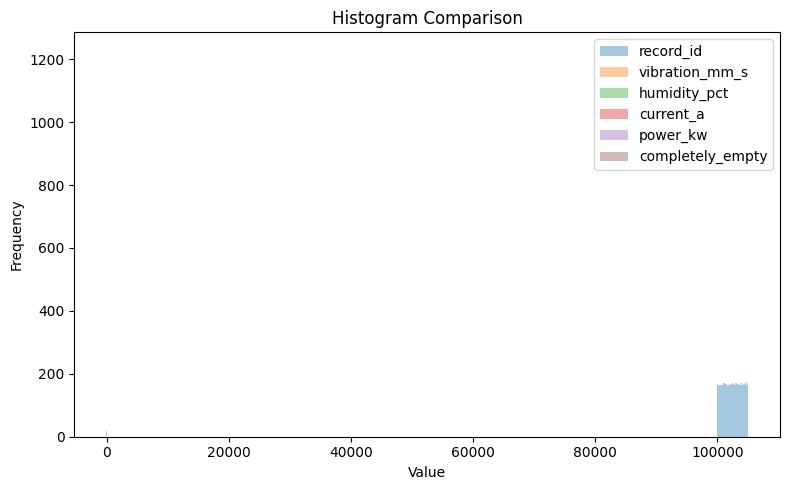


        Visualization Menu
1. Histogram
2. Boxplot
3. Distribution Plot
4. Scatter Plot
5. Bar Plot
6. Correlation Heatmap
7. Pairplot
8. All Visualizations
0. Exit



Select an option:  8



Available Numeric Columns:

1. record_id
2. vibration_mm_s
3. humidity_pct
4. current_a
5. power_kw
6. completely_empty
all. All Numeric Columns
0. Cancel



Enter column numbers separated by commas (example: 1,3,5), 'all', or 0:  all



Generating all visualizations...
Figure saved: figures\histogram_20260811_105216.png


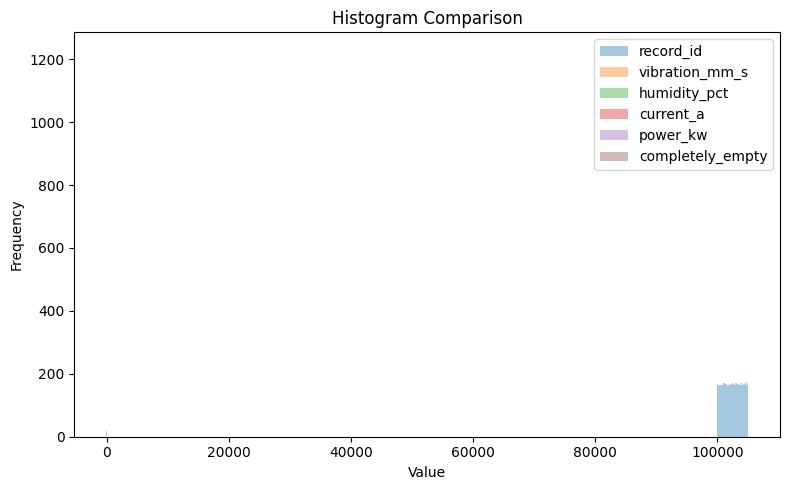

Figure saved: figures\boxplot_20260811_105217.png


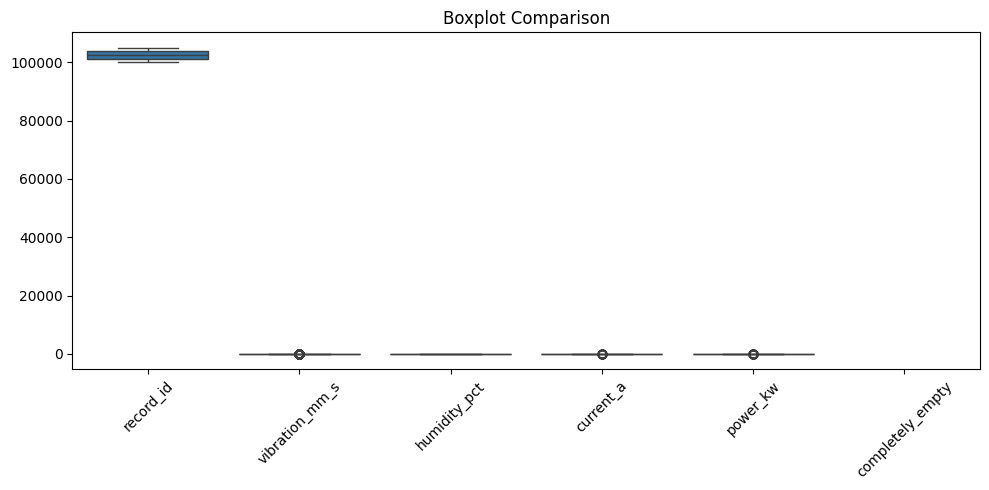

Figure saved: figures\distribution_20260811_105218.png


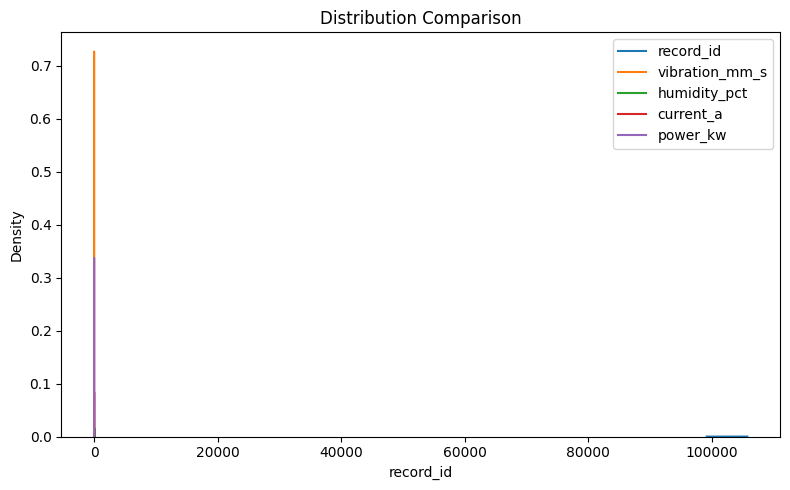

Figure saved: figures\heatmap_20260811_105219.png


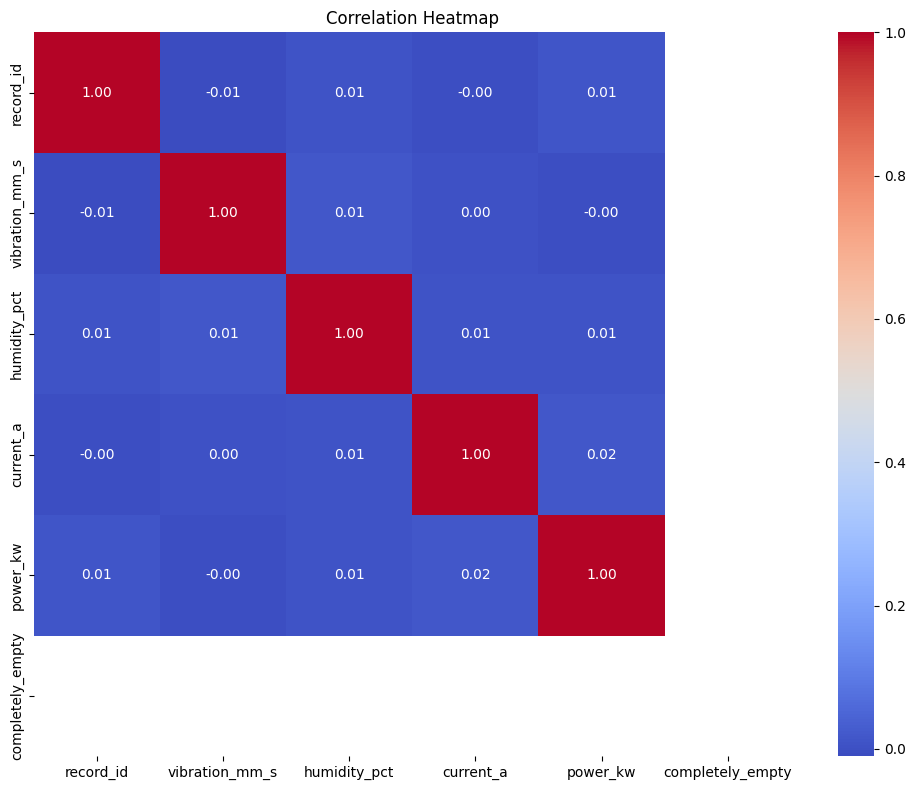

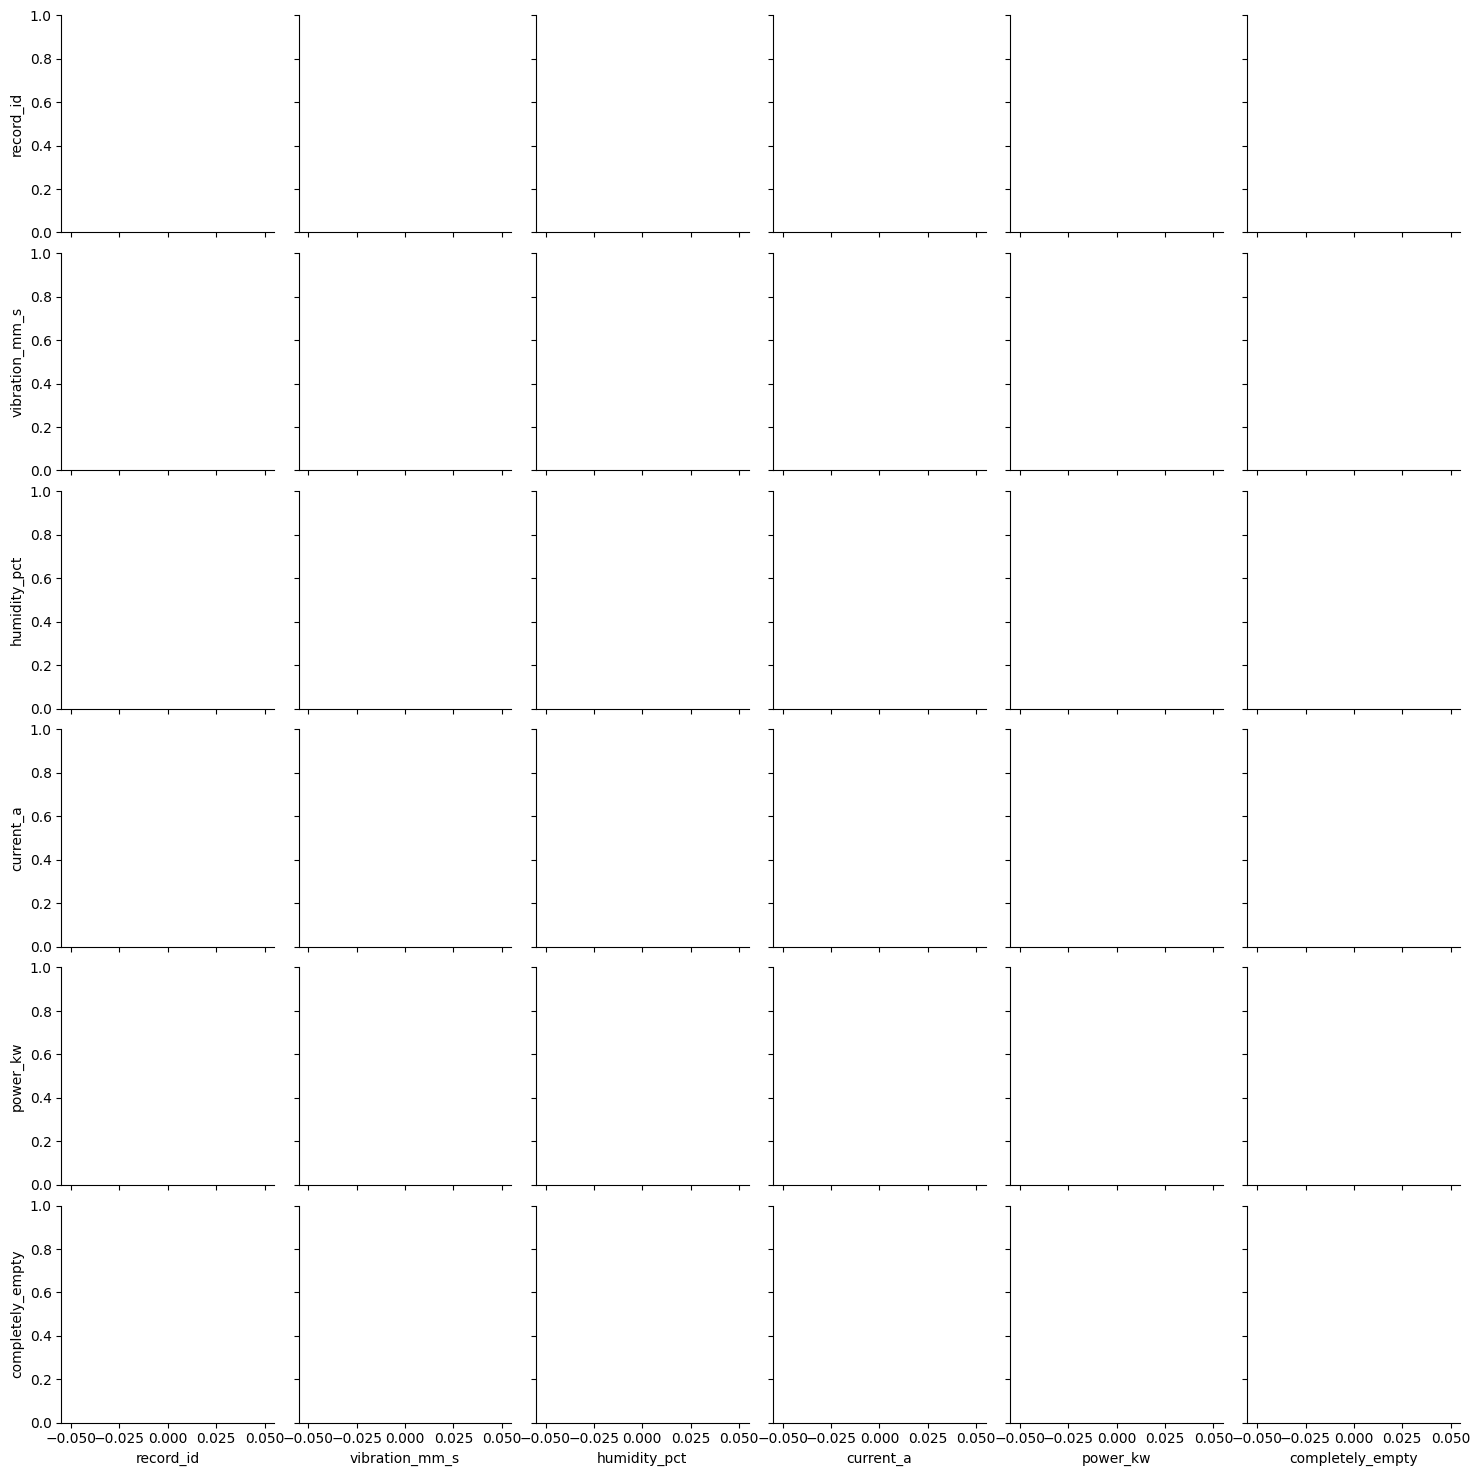


All visualizations completed.

        Visualization Menu
1. Histogram
2. Boxplot
3. Distribution Plot
4. Scatter Plot
5. Bar Plot
6. Correlation Heatmap
7. Pairplot
8. All Visualizations
0. Exit



Select an option:  0



Visualization menu closed.


In [40]:
visualize(df)

## 💾 Export Dataset

If the dataset has been cleaned, it can now be exported for further use.

In [46]:
display(Markdown("### 💾 Export Cleaned Dataset"))

print("1. CSV")
print("2. Excel")
print("3. Both")
print("4. Skip")

while True:

    choice = input("\nSelect an option (1-4): ").strip()

    if choice == "1":

        export_dataset(
            df,
            ".csv"
        )

        break

    elif choice == "2":

        export_dataset(
            df,
            ".xlsx"
        )

        break

    elif choice == "3":

        export_dataset(
            df,
            ".csv"
        )

        export_dataset(
            df,
            ".xlsx"
        )

        break

    elif choice == "4":

        print("Export skipped.")
        break

    else:

        print("❌ Invalid selection.")

### 💾 Export Cleaned Dataset

1. CSV
2. Excel
3. Both
4. Skip



Select an option (1-4):  0


❌ Invalid selection.



Select an option (1-4):  4


Export skipped.


# ✅ Analysis Completed

The analysis has been completed successfully.

The dataset has been:

- Loaded
- Summarized
- Checked for data quality
- Analyzed for missing values
- Analyzed for outliers
- Cleaned
- Visualized
- Exported (optional)

Thank you for using **GenericEDA**.